# Prepare street network for routing analysis

This notebook prepares the street network used for analysing routes to schools.

The network is derived from OpenStreetMap data and will later be used to compute routes and accessibility between homes and schools.

## Load the libraries needed for network preparation

Here we import the libraries needed to load spatial layers, work with OpenStreetMap data, and visualize the network.

In [1]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt

## Load the official school district polygons

Here we load the official district polygons that define the study area.

These polygons will be merged into one municipality-wide boundary and used to download the street network.

In [2]:
schools = gpd.read_file(
    "../data/processed/core_layers.gpkg",
    layer="schools"
)

districts = gpd.read_file(
    "../data/processed/core_layers.gpkg",
    layer="school_districts"
)

In [3]:
districts.head()

,temakode,temanavn,objekt_id,versions_i,systid_fra,systid_til,oprettet,cvr_kode,cvr_navn,kommunekod,...,starttrin,sluttrin_k,slutttrin,sagsnr,link,udd_hovedo,udd_hove_1,udd_delomr,udd_delo_1,geometry
0,5710,t_5710_born_skole_dis_t,caebf878-f997-11ea-8ef4-06d09fa510f4,4af5ce08-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((724468.727 6174207.618, 724824.483 6..."
1,5710,t_5710_born_skole_dis_t,caec40da-f997-11ea-8efa-06d09fa510f4,4af9587a-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((723566.615 6172586.107, 723670..."
2,5710,t_5710_born_skole_dis_t,caf771da-f997-11ea-8f2a-06d09fa510f4,4afad1e6-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((724798.236 6169075.917, 724761.682 6..."
3,5710,t_5710_born_skole_dis_t,cae99b50-f997-11ea-8eca-06d09fa510f4,4afbefd6-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((723570.181 6175053.926, 723568.928 6..."
4,5710,t_5710_born_skole_dis_t,caf6d3e2-f997-11ea-8f20-06d09fa510f4,4afd1a5a-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((724592.495 6177975.285, 724787.236 6..."


## Merge the district polygons into one study area

Here we combine all school district polygons into one geometry representing the overall study area.

This boundary will be used to request the bike network from OpenStreetMap.

In [4]:
study_area = districts.dissolve()
study_area

/Users/peterkriegel/Documents/ITU/2026/Researchproject/safe-school-paths-cph/.pixi/envs/default/lib/python3.9/site-packages/shapely/set_operations.py:426: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)


,geometry,temakode,temanavn,objekt_id,versions_i,systid_fra,systid_til,oprettet,cvr_kode,cvr_navn,...,starttrin_,starttrin,sluttrin_k,slutttrin,sagsnr,link,udd_hovedo,udd_hove_1,udd_delomr,udd_delo_1
0,"MULTIPOLYGON (((721535.268 6171337.076, 720874...",5710,t_5710_born_skole_dis_t,caebf878-f997-11ea-8ef4-06d09fa510f4,4af5ce08-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,...,11,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN


## Convert the study area to WGS84

OSMnx expects the boundary geometry in latitude/longitude coordinates.

Here we convert the study area to EPSG:4326 before downloading the network.

In [5]:
study_area_wgs84 = study_area.to_crs(4326)

In [6]:
study_area_wgs84

,geometry,temakode,temanavn,objekt_id,versions_i,systid_fra,systid_til,oprettet,cvr_kode,cvr_navn,...,starttrin_,starttrin,sluttrin_k,slutttrin,sagsnr,link,udd_hovedo,udd_hove_1,udd_delomr,udd_delo_1
0,"MULTIPOLYGON (((12.52000 55.63733, 12.50923 55...",5710,t_5710_born_skole_dis_t,caebf878-f997-11ea-8ef4-06d09fa510f4,4af5ce08-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,...,11,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN


## Extract the polygon geometry

The dissolved study area is stored as a GeoDataFrame. Here we extract the polygon geometry itself so it can be used directly in OSMnx.

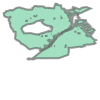

In [7]:
polygon = study_area_wgs84.geometry.iloc[0]
polygon

## We need to define which tags is useful to get from OSM

In [8]:
ox.settings.useful_tags_way = [
    "highway",
    "cycleway",
    "cycleway:left",
    "cycleway:right",
    "bicycle",
    "maxspeed",
    "surface",
    "name",
    "oneway"
]

## Download the bike network within the study area

Here we download the bike network from OpenStreetMap using the study area polygon rather than a place name.

In [9]:
G = ox.graph_from_polygon(
    polygon,
    network_type="bike"
)

/Users/peterkriegel/Documents/ITU/2026/Researchproject/safe-school-paths-cph/.pixi/envs/default/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/peterkriegel/Documents/ITU/2026/Researchproject/safe-school-paths-cph/.pixi/envs/default/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/peterkriegel/Documents/ITU/2026/Researchproject/safe-school-paths-cph/.pixi/envs/default/lib/python3.9/site-packages/shapely/set_operations.py:340: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)
/Users/peterkriegel/Documents/ITU/2026/Researchproject/safe-school-paths-cph/.pixi/envs/default/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/peterkriegel/Documents/ITU/2026/

## Check the size of the network

In [10]:
len(G.nodes), len(G.edges)

(22298, 54170)

## Plot the downloaded bike network

Here we make a quick plot of the network to visually check whether it looks like a realistic street network for Copenhagen.

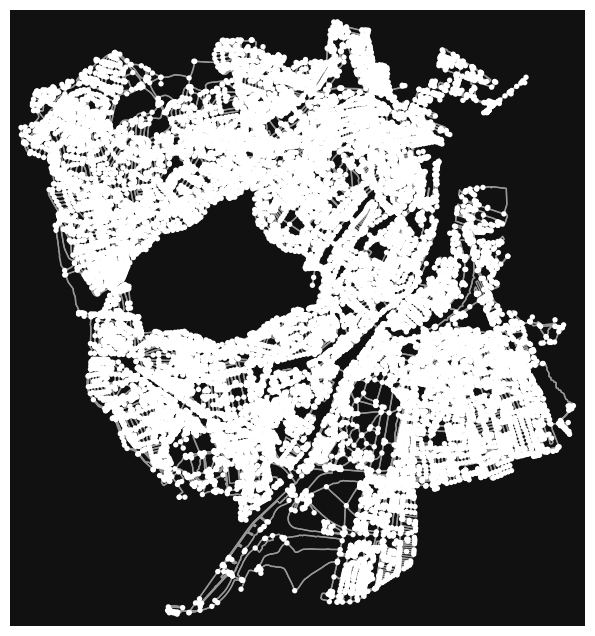

In [11]:
fig, ax = ox.plot_graph(G)

## Convert the graph into GeoDataFrames

Here we convert the network graph into node and edge GeoDataFrames so the road segments can be plotted together with schools and districts.

In [12]:
nodes, edges = ox.graph_to_gdfs(G)

## Reproject the network to the common project CRS

The schools and district polygons are already stored in EPSG:25832.

Here we convert the network layers to the same CRS so they can be overlaid directly.

In [13]:
edges = edges.to_crs(25832)
nodes = nodes.to_crs(25832)

## Plot the network together with districts and schools

This map is used as a visual sanity check to confirm that the road network, school district polygons, and school locations line up correctly.

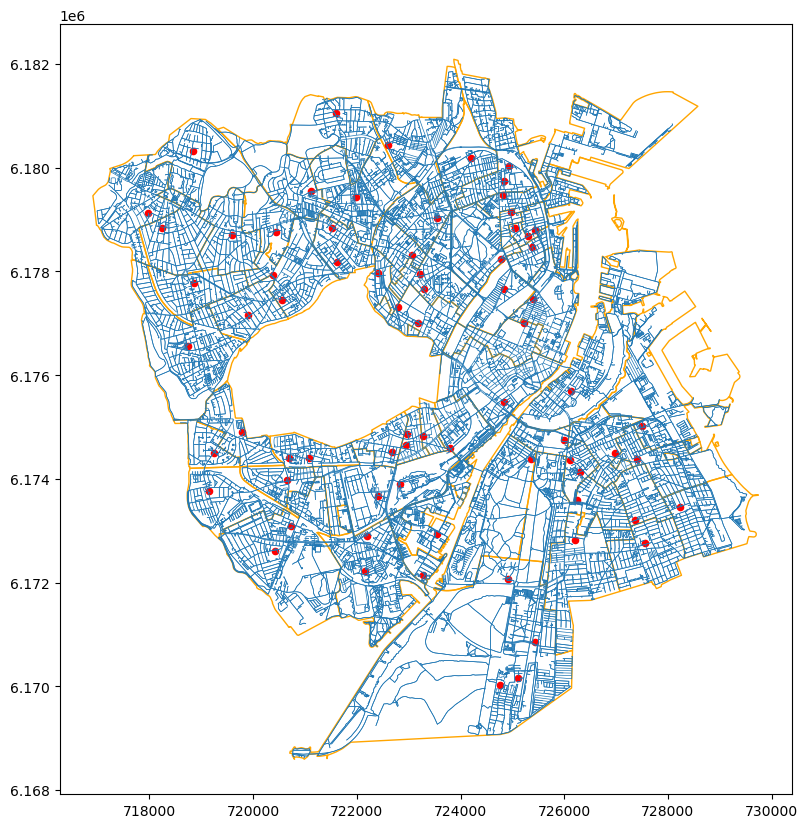

In [14]:
ax = edges.plot(figsize=(10, 10), linewidth=0.5)
districts.plot(ax=ax, edgecolor="orange", facecolor="none")
schools.plot(ax=ax, color="red", markersize=20)

plt.show()

## Save the prepared network

Finally we save the downloaded bike network so it can be reused later without downloading it again.

In [15]:
ox.save_graphml(G, "../data/processed/cph_bike_network.graphml")

### Prepare edge attributes for export

Some OSM attributes are stored as lists, but GeoPackage formal does not support list-type values.
Here we convert any list-type attributes into strings, so that the dataset can be saved properly.

In [16]:
for col in edges.columns:
    if edges[col].apply(lambda x: isinstance(x, list)).any():
        edges[col] = edges[col].astype(str)

### Save edge layer for later use

The cleaned edge GeoDataFrame is saved as a GeoPackage layer.
This allows us to reuse the processed network.

In [17]:
edges.to_file(
    "../data/processed/network_layers.gpkg",
    layer="bike_edges",
    driver="GPKG"
)

## We want to look at the different tags the edges hold

### INspect available edge attributes

Before denining safe cycling paths, we inspect shich OSM tags are available in the edges.

These attributes describe the road segments and include information such as surface, maxspeed, cycleway.

In [18]:
edges.columns.to_list()

['osmid',
 'highway',
 'cycleway:left',
 'cycleway:right',
 'maxspeed',
 'surface',
 'name',
 'oneway',
 'reversed',
 'length',
 'bicycle',
 'geometry',
 'cycleway']

## We want to inspect the actual values in the different tags

### Explore road types in the network

The highway tag is the main OSM attribute used to secribe what kind of road or path each edge represents.

Inspecting its most frequent values helps identify which street and path types are most common in the network.

In [19]:
edges["highway"].value_counts().head(20)

highway
residential                         18162
service                             17142
tertiary                             6434
path                                 4392
cycleway                             3696
unclassified                         1144
primary                               598
living_street                         572
pedestrian                            538
secondary                             208
['path', 'service']                   158
['residential', 'service']            143
track                                 138
['residential', 'cycleway']           113
tertiary_link                          87
['residential', 'living_street']       72
['residential', 'path']                70
['path', 'residential']                65
['path', 'cycleway']                   54
busway                                 48
Name: count, dtype: int64

### Explore the general cycling infrastructure tags

The cycleway tag descibes whether a road segment has cycling infrastructure attached to it, such as a lane or a track.

Inspecting these values helps identify how protected bike paths are represented in the data.

In [20]:
edges["cycleway"].value_counts().head(20)

cycleway
nan                                      47152
track                                     4059
no                                        1921
separate                                   505
lane                                       265
crossing                                   202
shared_lane                                 16
shared                                      14
['track', 'no']                             12
['track', 'lane']                            6
['lane', 'no']                               3
construction                                 3
opposite_track                               2
opposite                                     2
['no', 'shared']                             2
['crossing', 'shared', 'shared_lane']        2
link                                         1
designated                                   1
['crossing', 'designated']                   1
opposite_lane                                1
Name: count, dtype: int64

### Explore the left-side cycling infrastructure

Some roads store cycling infrastructure seperately for the left and right side of the carriageway.

Here we inspect the values on the left side to understand how side-specific bicycle facilities are encoded.

In [21]:
edges["cycleway:left"].value_counts().head(20)

cycleway:left
nan                            52462
no                              1058
separate                         234
track                            222
lane                             131
use_sidepath                      24
opposite_track                    11
opposite_lane                     11
['track', 'lane']                  7
['track', 'no']                    2
shared_lane                        2
['lane', 'shared_lane']            2
['separate', 'no']                 2
['lane', 'no']                     1
['track', 'opposite_track']        1
Name: count, dtype: int64

### Explore the right-side cycling infrastructure

We do the same as the cell above, just for the right cycleway attribute.

In [22]:
edges["cycleway:right"].value_counts().head(20)

cycleway:right
nan                                 51219
track                                1498
separate                              695
no                                    340
lane                                  254
shared_lane                            90
['track', 'lane']                      28
['track', 'shared_lane']               15
share_busway                            8
['no', 'shared_lane']                   4
shoulder                                4
['track', 'no']                         3
['separate', 'no']                      3
['separate', 'track']                   2
['lane', 'no']                          2
use_sidepath                            2
['lane', 'shared_lane']                 2
['track', 'lane', 'shared_lane']        1
Name: count, dtype: int64

### Explore bicycle access tags

The bicycle tag describtes whether cuycling is allowed, designated, restricted or redireted.

This attribute helps interpret whether a road segment is intended to be uysed by cyclists.

In [23]:
edges["bicycle"].value_counts()

bicycle
nan                        47222
yes                         2905
designated                  2290
use_sidepath                1563
dismount                     106
['yes', 'designated']         35
permissive                    26
private                       14
destination                    6
['use_sidepath', 'yes']        3
Name: count, dtype: int64

## Define safety criteria for the cycling network

### Define a helper function for mixed attribute formats

OSM attributes may be stored either as single values or as lists of multiple values.

This helper function checks whether an attribute contains any value from a set of target values, regardless of whether the attribute is stores a a single value or a list.

In [24]:
def has_value(x, valid_values):
    if isinstance(x, list):
        return any(v in valid_values for v in x)
    return x in valid_values

### Define protected cycling infrastructure

Protected cycling infrastructure is treated as the safest category in the network.

Here, dedicated cycleways (highway = cycleway) and separated cycle track (cycle = track or opposite track) are defined as protected infrastructure.

In [25]:
protected_cycleway_values = {
    "track",
    "opposite_track"
}

protected_highway_values = {
    "cycleway"
}

### Identify protected network edges

Using the protected infrastructure definitions above, each edge is classified as protected or not protected via boolean expressions.

An edge is considered protected if it is either:
- a dedicated cycleway
 OR
- a road with a protected cycle track recorded in any of the cycleway-related tags.

In [26]:
edges["is_protected"] = (
    edges["highway"].apply(lambda x: has_value(x, protected_highway_values)) |
    edges["cycleway"].apply(lambda x: has_value(x, protected_cycleway_values)) |
    edges["cycleway:left"].apply(lambda x: has_value(x, protected_cycleway_values)) |
    edges["cycleway:right"].apply(lambda x: has_value(x, protected_cycleway_values))
)

### Define local street types

In addition to protected ifrastructure, low-speed local streets are considered potentially suitable for safe cycling.

The selected road types represent streets that typically carry less traffic and lower speeds than majer roads.

In [27]:
low_speed_highways = {
    "residential",
    "living_street",
    "service",
    "unclassified"
}

### Convert speed limits to numeric format

This function below extracts a numeric value so that speed limits can be used consistently in a safety classification.

In [28]:
def parse_maxspeed(x):
    if isinstance(x, list):
        x = x[0]
    if isinstance(x, (int, float)):
        return x
    if isinstance(x, str):
        digits = "".join(ch for ch in x if ch.isdigit())
        if digits:
            return float(digits)
    return None

### Create numeric speed column

This speed parsing function is applied to all edges to create a numeric speed limit column for later filtering if nessesary.

In [29]:
edges["maxspeed_num"] = edges["maxspeed"].apply(parse_maxspeed)

### Identify low-speed local streets

An edge is classified as a low speed street if its road type is local and its speed limit is either missing or at most 30 km/h

This captures calmer streets that may be acceptable for child cyclingeven when they are not protected.

In [30]:
edges["is_low_speed"] = (
    edges["highway"].apply(lambda x: has_value(x, low_speed_highways)) &
    (
        (edges["maxspeed_num"].isna()) |   
        (edges["maxspeed_num"] <= 30)
    )
)

### Combine safety criteria into one classification

The final safety classification combines two route types:
- protected cycling infrastructure
- low speed local streets

An edge is marked as safe if it satiefies at least one of these conditions.

In [31]:
edges["is_safe"] = (
    edges["is_protected"] |
    edges["is_low_speed"]
)

### Extract the safe cycling network

Using binary safety classification, the network is filtered so that only safe edges remain.

This subset represents the cycling network that will later be used for safe-route analysis.

In [32]:
safe_edges = edges[edges["is_safe"]].copy()

### Visualise the safe cycling network

The final map shows the safe cycling network on top of the full network.

This provides a visual validation of whether the safety definition produces a realistic and cennected city-wide network.

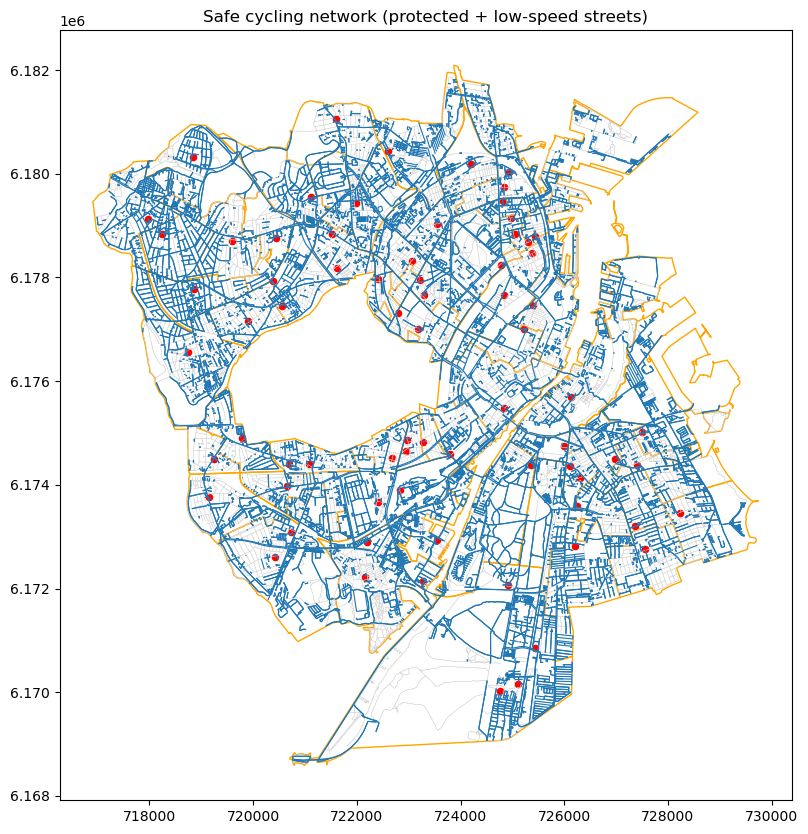

In [33]:
ax = edges.plot(figsize=(10, 10), color="lightgrey", linewidth=0.3)
safe_edges.plot(ax=ax, linewidth=0.8)

districts.plot(ax=ax, edgecolor="orange", facecolor="none")
schools.plot(ax=ax, color="red", markersize=20)

plt.title("Safe cycling network (protected + low-speed streets)")
plt.show()

## Anastassias safe cycling network

In [34]:
anastassia_safe_highways = {
    "track",
    "path",
    "footway",
    "living_street"
}

In [35]:
def highway_is_safe(x):
    if isinstance(x, list):
        return any(v in anastassia_safe_highways for v in x)
    return x in anastassia_safe_highways

edges["is_safe_anastassia"] = edges["highway"].apply(highway_is_safe)

safe_edges_anastassia = edges[edges["is_safe_anastassia"]].copy()

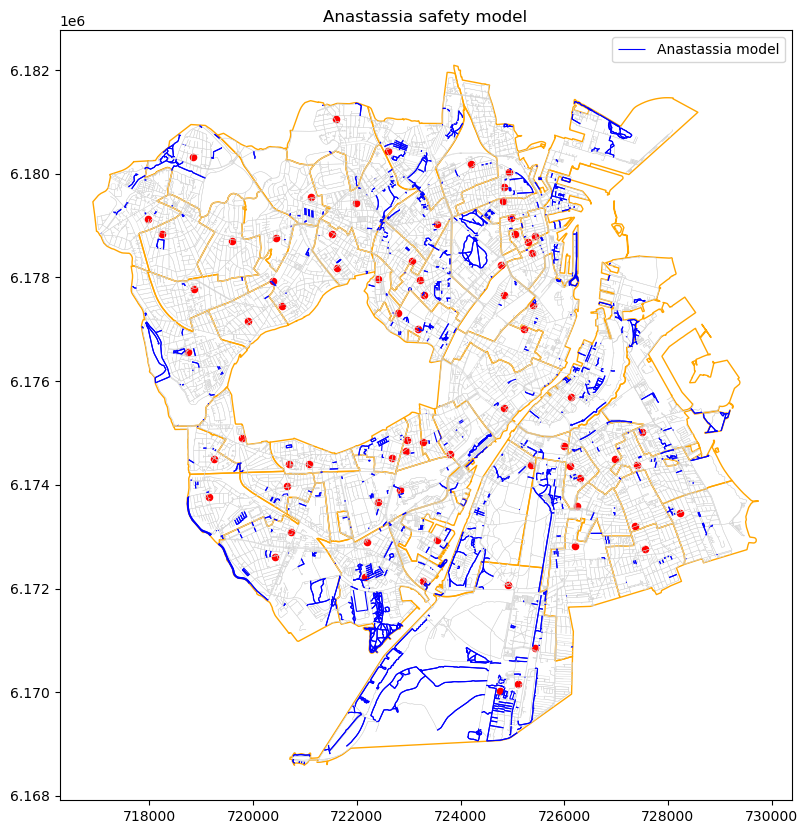

In [37]:
fig, ax = plt.subplots(figsize=(10, 10))


edges.plot(ax=ax, color="lightgrey", linewidth=0.3)

# My safe network (green)
# safe_edges.plot(ax=ax, color="green", linewidth=0.8, label="My model")

# Anastassia safe network (blue)
safe_edges_anastassia.plot(ax=ax, color="blue", linewidth=0.8, label="Anastassia model")

districts.plot(ax=ax, edgecolor="orange", facecolor="none")
schools.plot(ax=ax, color="red", markersize=20)

plt.title("Anastassia safety model")
plt.legend()
plt.show()

## Test to see which roads exist in Copenhagen

In [38]:
def test_highway_is_safe(row):
    highway = row["highway"]
    cycleway = row["cycleway"]

    def has_value(x, value):
        if isinstance(x, list):
            return value in x
        return x == value

    return has_value(highway, "primary") and has_value(cycleway, "track")

In [39]:
edges["is_safe_test"] = edges.apply(test_highway_is_safe, axis=1)

NameError: name 'safe_edges_test' is not defined

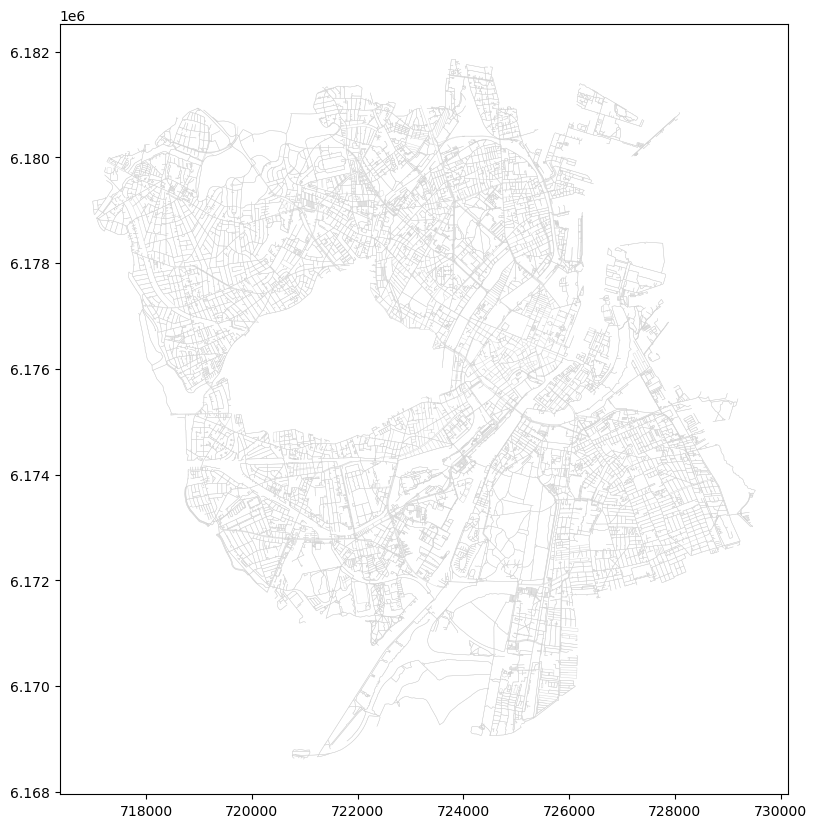

In [40]:
fig, ax = plt.subplots(figsize=(10, 10))


edges.plot(ax=ax, color="lightgrey", linewidth=0.3)

# Test plot to see roads in Copenhagen
safe_edges_test.plot(ax=ax, color="blue", linewidth=0.8, label="Test model")

districts.plot(ax=ax, edgecolor="orange", facecolor="none")
schools.plot(ax=ax, color="red", markersize=20)

plt.title("Test safety model")
plt.legend()
plt.show()

In [41]:
edges["highway"].value_counts().head(20)

highway
residential                         18162
service                             17142
tertiary                             6434
path                                 4392
cycleway                             3696
unclassified                         1144
primary                               598
living_street                         572
pedestrian                            538
secondary                             208
['path', 'service']                   158
['residential', 'service']            143
track                                 138
['residential', 'cycleway']           113
tertiary_link                          87
['residential', 'living_street']       72
['residential', 'path']                70
['path', 'residential']                65
['path', 'cycleway']                   54
busway                                 48
Name: count, dtype: int64